# CosyPose Evaluation on synth6d Synthetic Renders

Evaluates the pre-trained CosyPose model (trained on BOP synthetic data) on our own
synthetic renders. Uses ground-truth bounding boxes so we measure pose estimation
accuracy independently of detection quality.

**Metric:** ADD (Average Distance of Model Points)  
**Threshold:** ADD < 10% of object diameter = correct prediction

## Cell 1: Install Dependencies

In [15]:
import os, sys

os.environ["HAPPYPOSE_DATA_DIR"] = "/kaggle/working/happypose_data"
os.makedirs(os.environ["HAPPYPOSE_DATA_DIR"], exist_ok=True)

!git clone --branch dev --recurse-submodules https://github.com/agimus-project/happypose.git \
    /kaggle/working/happypose -q
os.chdir("/kaggle/working/happypose")

# bop_toolkit is not on PyPI, install from git
!pip install "git+https://github.com/agimus-project/bop_toolkit@ba22a74dff2b395d83982774333b065ae47a51d4" \
    -q > /dev/null 2>&1

# bop_toolkit pins an old Pillow that breaks torchvision later, restore a modern version
!pip install "pillow>=10.0.0" -q > /dev/null 2>&1

# install happypose + cosypose without resolving the full dependency tree (the resolver hangs
# on this many packages); Kaggle already has torch/numpy/etc, install only what's missing below
!pip install -e . -e ./happypose/pose_estimators/cosypose --no-deps -q > /dev/null 2>&1

# packages happypose/cosypose import but that --no-deps skipped
!pip install \
    pybullet \
    transforms3d \
    "roma>=1.5.0" \
    "trimesh>=4.5.1" \
    "plyfile>=1.1" \
    "addict>=2.4.0" \
    "torchnet>=0.0.4" \
    "torchtnt>=0.2.4" \
    "hydra-core" \
    "panda3d" \
    "pin" \
    "meshcat" \
    "bokeh" \
    "webdataset" \
    "braceexpand" \
    "beautifulsoup4" \
    -q > deps_log.txt 2>&1

# the pin (pinocchio) install above downgrades Pillow again, restore once more
!pip install "pillow==10.4.0" --force-reinstall --no-deps -q > /dev/null 2>&1

# pin uses cmeel packaging; its .pth file only runs at interpreter startup, so for an
# already-running kernel we add the path manually
cmeel_path = "/usr/local/lib/python3.12/dist-packages/cmeel.prefix/lib/python3.12/site-packages"
if cmeel_path not in sys.path:
    sys.path.append(cmeel_path)

!grep -i "^ERROR" deps_log.txt | head -10
print("Setup complete")

fatal: destination path '/kaggle/working/happypose' already exists and is not an empty directory.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
Setup complete


In [16]:
import sys
from unittest.mock import MagicMock

# happypose imports pybullet at module level but we only use the panda3d renderer;
# the installed pybullet build is incompatible with numpy 2.x, so mock it instead
sys.modules["pybullet"] = MagicMock()

import torch
print(f"torch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
print("pybullet mocked, ready to proceed")

torch: 2.10.0+cu128, CUDA: True
pybullet mocked — ready to proceed


## Cell 2: Verify Installation

In [17]:
import importlib
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

required = ["happypose", "pinocchio", "omegaconf", "bop_toolkit_lib", "panda3d"]
for pkg in required:
    try:
        importlib.import_module(pkg)
        print(f"{pkg}: OK")
    except ImportError as e:
        print(f"{pkg}: MISSING - {e}")

from happypose.pose_estimators.cosypose.cosypose.config import LOCAL_DATA_DIR
print(f"\nHappyPose data dir: {LOCAL_DATA_DIR}")

PyTorch: 2.10.0+cu128
CUDA: True
happypose: OK
pinocchio: OK
omegaconf: OK
bop_toolkit_lib: OK
panda3d: OK

HappyPose data dir: /kaggle/working/happypose_data


## Cell 3: Download Pretrained CosyPose YCB-V Models

In [18]:
# Download coarse + refiner models pretrained on BOP YCB-V synthetic data
!python -m happypose.toolbox.utils.download \
    --cosypose_models \
    coarse-bop-ycbv-pbr--724183 \
    refiner-bop-ycbv-pbr--604090

# Download YCB-V extra files (friendly names, offsets, keyframes)
!python -m happypose.toolbox.utils.download --bop_extra_files ycbv > /dev/null 2>&1

print("\nModels downloaded:")
!ls /kaggle/working/happypose_data/experiments/

Setting OMP and MKL num threads to 1.
0:00:03.233754 - Copying https://www.paris.inria.fr/archive_ylabbeprojectsdata/cosypose/experiments/coarse-bop-ycbv-pbr--724183/ to /kaggle/working/happypose_data/experiments/coarse-bop-ycbv-pbr--724183
0:00:03.854043 - Skipping https://www.paris.inria.fr/archive_ylabbeprojectsdata/cosypose/experiments/coarse-bop-ycbv-pbr--724183/checkpoint.pth.tar already fully downloaded
0:00:04.459089 - Copying https://www.paris.inria.fr/archive_ylabbeprojectsdata/cosypose/experiments/coarse-bop-ycbv-pbr--724183/log.txt to /kaggle/working/happypose_data/experiments/coarse-bop-ycbv-pbr--724183/log.txt
0:00:04.771875 - Copying https://www.paris.inria.fr/archive_ylabbeprojectsdata/cosypose/experiments/refiner-bop-ycbv-pbr--604090/ to /kaggle/working/happypose_data/experiments/refiner-bop-ycbv-pbr--604090
0:00:04.979443 - Skipping https://www.paris.inria.fr/archive_ylabbeprojectsdata/cosypose/experiments/coarse-bop-ycbv-pbr--724183/config.yaml already fully download

## Cell 4: Mount synth6d Dataset and BOP YCB-V Models

In [19]:
import json
import numpy as np
from pathlib import Path

# synth6d BOP dataset on Kaggle
SYNTH6D_BOP = Path("/kaggle/input/datasets/dushyant0811/synth6d-ycb-pose-dataset/bop/train_pbr")

# BOP YCB-V 3D models, from ycbv_models.zip uploaded as a separate Kaggle dataset
YCBV_MODELS = Path("/kaggle/input/datasets/dushyant0811/ycbv-models/models")

print(f"synth6d BOP: {SYNTH6D_BOP.exists()} - {SYNTH6D_BOP}")
print(f"YCB models:  {YCBV_MODELS.exists()} - {YCBV_MODELS}")

scene_folders = sorted(SYNTH6D_BOP.iterdir())
print(f"\nScene folders: {len(scene_folders)}")
for sf in scene_folders:
    n_rgb = len(list((sf / "rgb").glob("*.jpg")))
    print(f"  {sf.name}: {n_rgb} images")

synth6d BOP: True — /kaggle/input/datasets/dushyant0811/synth6d-ycb-pose-dataset/bop/train_pbr
YCB models:  True — /kaggle/input/datasets/dushyant0811/ycbv-models/models

Scene folders: 8
  000000: 200 images
  000001: 300 images
  000002: 200 images
  000003: 300 images
  000004: 200 images
  000005: 300 images
  000006: 300 images
  000007: 200 images


## Cell 5: Object ID Mapping (synth6d → BOP YCB-V)

In [20]:
# Our category_id_map from build_category_id_map() in utils.py
# Pool order determines ID: pool[0] -> id 1, pool[1] -> id 2, etc.
SYNTH6D_POOL = [
    "002_master_chef_can",
    "003_cracker_box",
    "004_sugar_box",
    "006_mustard_bottle",
    "017_orange",
    "021_bleach_cleanser",
    "024_bowl",
    "025_mug",
    "035_power_drill",
    "051_large_clamp",
]
SYNTH6D_ID_TO_NAME = {idx + 1: name for idx, name in enumerate(SYNTH6D_POOL)}

# BOP YCB-V uses a different numbering (21 objects total)
# Mapping: our synth6d obj_id -> BOP YCB-V obj_id
# 017_orange is NOT in BOP YCB-V so it's excluded from evaluation
SYNTH6D_TO_BOP = {
    1:  1,    # 002_master_chef_can
    2:  2,    # 003_cracker_box
    3:  3,    # 004_sugar_box
    4:  5,    # 006_mustard_bottle
    5:  None, # 017_orange — not in BOP YCB-V, skip
    6:  12,   # 021_bleach_cleanser
    7:  13,   # 024_bowl
    8:  14,   # 025_mug
    9:  15,   # 035_power_drill
    10: 19,   # 051_large_clamp
}

# CosyPose label format: "ycbv-obj_XXXXXX"
def bop_id_to_label(bop_id: int) -> str:
    return f"ycbv-obj_{bop_id:06d}"

print("synth6d obj_id -> BOP obj_id -> CosyPose label:")
for s_id, b_id in SYNTH6D_TO_BOP.items():
    name = SYNTH6D_ID_TO_NAME[s_id]
    label = bop_id_to_label(b_id) if b_id else "SKIP"
    print(f"  {s_id:2d} ({name:25s}) -> {str(b_id):4s} -> {label}")

synth6d obj_id -> BOP obj_id -> CosyPose label:
   1 (002_master_chef_can      ) -> 1    -> ycbv-obj_000001
   2 (003_cracker_box          ) -> 2    -> ycbv-obj_000002
   3 (004_sugar_box            ) -> 3    -> ycbv-obj_000003
   4 (006_mustard_bottle       ) -> 5    -> ycbv-obj_000005
   5 (017_orange               ) -> None -> SKIP
   6 (021_bleach_cleanser      ) -> 12   -> ycbv-obj_000012
   7 (024_bowl                 ) -> 13   -> ycbv-obj_000013
   8 (025_mug                  ) -> 14   -> ycbv-obj_000014
   9 (035_power_drill          ) -> 15   -> ycbv-obj_000015
  10 (051_large_clamp          ) -> 19   -> ycbv-obj_000019


## Cell 6: Load Ground Truth Poses and Compute GT Detections

In [21]:
import cv2
import json
import numpy as np
from pathlib import Path

def load_scene_data(scene_path: Path, max_frames: int = 20):
    """
    Load RGB images, GT poses, K matrices and GT bounding boxes
    from a synth6d BOP scene folder.
    Returns list of frame dicts ready for CosyPose inference.
    """
    with open(scene_path / "scene_gt.json") as f:
        scene_gt = json.load(f)
    with open(scene_path / "scene_camera.json") as f:
        scene_camera = json.load(f)
    with open(scene_path / "scene_gt_info.json") as f:
        scene_gt_info = json.load(f)

    frames = []
    frame_ids = sorted(scene_gt.keys(), key=int)[:max_frames]

    for frame_id in frame_ids:
        img_path = scene_path / "rgb" / f"{int(frame_id):06d}.jpg"
        if not img_path.exists():
            continue

        bgr = cv2.imread(str(img_path))
        if bgr is None:
            continue
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

        cam_data = scene_camera[frame_id]
        K = np.array(cam_data["cam_K"]).reshape(3, 3)

        gt_objects = []
        for gt_obj, gt_info in zip(scene_gt[frame_id], scene_gt_info[frame_id]):
            synth_id = gt_obj["obj_id"]
            bop_id   = SYNTH6D_TO_BOP.get(synth_id)

            if bop_id is None:
                continue
            if gt_info.get("visib_fract", 0) < 0.1:
                continue

            R_gt = np.array(gt_obj["cam_R_m2c"]).reshape(3, 3)
            t_gt = np.array(gt_obj["cam_t_m2c"]) / 1000.0  # mm -> m
            bbox = gt_info.get("bbox_visib", gt_info.get("bbox_obj", None))

            gt_objects.append({
                "synth_id": synth_id,
                "bop_id":   bop_id,
                "label":    bop_id_to_label(bop_id),
                "R_gt":     R_gt,
                "t_gt":     t_gt,
                "bbox":     bbox,  # [x, y, w, h]
            })

        if gt_objects:
            frames.append({
                "scene_id": scene_path.name,
                "frame_id": frame_id,
                "rgb":      rgb,
                "K":        K,
                "objects":  gt_objects,
            })

    return frames


ALL_FRAMES = []
FRAMES_PER_SCENE = 3

for scene_folder in scene_folders:
    frames = load_scene_data(scene_folder, max_frames=FRAMES_PER_SCENE)
    ALL_FRAMES.extend(frames)
    print(f"{scene_folder.name}: {len(frames)} frames loaded")

print(f"\nTotal frames: {len(ALL_FRAMES)}")
print(f"Total object instances: {sum(len(f['objects']) for f in ALL_FRAMES)}")

000000: 3 frames loaded
000001: 3 frames loaded
000002: 3 frames loaded
000003: 3 frames loaded
000004: 3 frames loaded
000005: 3 frames loaded
000006: 3 frames loaded
000007: 3 frames loaded

Total frames: 24
Total object instances: 137


## Cell 7: Load CosyPose Model

In [22]:
import torch
from happypose.pose_estimators.cosypose.cosypose.config import LOCAL_DATA_DIR
from happypose.pose_estimators.cosypose.cosypose.integrated.pose_estimator import PoseEstimator
from happypose.pose_estimators.cosypose.cosypose.training.pose_models_cfg import load_model_cosypose
from happypose.pose_estimators.cosypose.cosypose.lib3d.rigid_mesh_database import MeshDataBase
from happypose.toolbox.datasets.object_dataset import RigidObjectDataset, RigidObject
from happypose.toolbox.renderer.panda3d_batch_renderer import Panda3dBatchRenderer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Build object dataset from BOP YCB-V models
bop_ids_needed = [v for v in SYNTH6D_TO_BOP.values() if v is not None]
print(f"Loading {len(bop_ids_needed)} object models: {bop_ids_needed}")

objects = []
for bop_id in bop_ids_needed:
    ply_path = YCBV_MODELS / f"obj_{bop_id:06d}.ply"
    if ply_path.exists():
        objects.append(RigidObject(
            label=bop_id_to_label(bop_id),
            mesh_path=ply_path,
            mesh_units="mm",
        ))
    else:
        print(f"  WARNING: model not found: {ply_path}")

object_dataset = RigidObjectDataset(objects)
print(f"Loaded {len(object_dataset)} object models")

# Convert to BatchedMeshes using dicts (cosypose MeshDataBase expects dicts not RigidObject)
obj_dicts = [
    {"label": obj.label, "mesh_path": str(obj.mesh_path), "mesh_units": "mm"}
    for obj in objects
]
mesh_db         = MeshDataBase(obj_dicts)
mesh_db_batched = mesh_db.batched(n_sym=64).to(DEVICE)
print("Mesh database ready")

# Build renderer
renderer = Panda3dBatchRenderer(
    object_dataset,
    n_workers=4,
    preload_cache=False,
)

def load_pose_model(exp_name):
    exp_dir   = LOCAL_DATA_DIR / "experiments" / exp_name
    ckpt_path = exp_dir / "checkpoint.pth.tar"
    # mesh_db_batched not object_dataset — pose estimator needs BatchedMeshes
    model = load_model_cosypose(exp_dir, renderer, mesh_db_batched, DEVICE)
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    return model

print("Loading coarse model...")
coarse_model  = load_pose_model("coarse-bop-ycbv-pbr--724183")

print("Loading refiner model...")
refiner_model = load_pose_model("refiner-bop-ycbv-pbr--604090")

pose_estimator = PoseEstimator(
    refiner_model=refiner_model,
    coarse_model=coarse_model,
    detector_model=None,
)
print("Pose estimator ready")

Using device: cuda
Loading 9 object models: [1, 2, 3, 5, 12, 13, 14, 15, 19]
Loaded 9 object models
Mesh database ready


Known pipe types:
  glxGraphicsPipe
(1 aux display modules not yet loaded.)
Known pipe types:
  glxGraphicsPipe
(1 aux display modules not yet loaded.)


Loading coarse model...


Known pipe types:
  glxGraphicsPipe
(1 aux display modules not yet loaded.)
Known pipe types:
  glxGraphicsPipe
(1 aux display modules not yet loaded.)
0:21:41.605509 - Backbone: efficientnet-b3
INFO:happypose.pose_estimators.cosypose.cosypose.training.pose_models_cfg:Backbone: efficientnet-b3
0:21:42.363782 - Backbone: efficientnet-b3
INFO:happypose.pose_estimators.cosypose.cosypose.training.pose_models_cfg:Backbone: efficientnet-b3


Loading refiner model...
Pose estimator ready


## Cell 8: Run CosyPose Inference with GT Detections

In [23]:
from happypose.toolbox.inference.types import ObservationTensor
import pandas as pd

from happypose.toolbox.utils.tensor_collection import PandasTensorCollection

def run_inference_on_frame(frame: dict) -> list:
    rgb_np = frame["rgb"]
    K_np   = frame["K"]

    observation = ObservationTensor.from_numpy(rgb=rgb_np, K=K_np)
    observation = observation.cuda() if torch.cuda.is_available() else observation.cpu()

    # pose_estimator expects detections as a PandasTensorCollection, not a plain DataFrame
    det_rows  = []
    det_boxes = []
    for obj in frame["objects"]:
        bbox = obj["bbox"]
        if bbox is None:
            continue
        x, y, w, h = bbox
        det_rows.append({
            "label":      obj["label"],
            "batch_im_id": 0,
            "instance_id": len(det_rows),
            "score":       1.0,
        })
        det_boxes.append([x, y, x + w, y + h])  # xyxy format

    if not det_rows:
        return []

    infos_df = pd.DataFrame(det_rows)
    bboxes_t = torch.tensor(det_boxes, dtype=torch.float32).to(DEVICE)

    detections = PandasTensorCollection(
        infos=infos_df,
        bboxes=bboxes_t,
    )

    with torch.no_grad():
        output, _ = pose_estimator.run_inference_pipeline(
            observation,
            detections=detections,
            run_detector=False,
            n_refiner_iterations=5,
        )

    # output is a PandasTensorCollection with .infos and .poses
    preds_df = output.infos.copy()
    poses    = output.poses.cpu().numpy()

    results = []
    for obj in frame["objects"]:
        label = obj["label"]
        mask  = preds_df["label"] == label
        if not mask.any():
            continue

        best_idx  = preds_df[mask]["score"].idxmax()
        best_pose = poses[best_idx]

        # one-time check that predicted and GT translations are in the same units
        if not globals().get('_unit_check_done', False):
            print("[unit check] t_pred raw (expect ~hundreds = mm):", best_pose[:3, 3])
            print("[unit check] t_gt      (expect ~<1      = m):  ", obj["t_gt"])
            globals()['_unit_check_done'] = True

        results.append({
            "scene_id": frame["scene_id"],
            "frame_id": frame["frame_id"],
            "label":    label,
            "bop_id":   obj["bop_id"],
            "R_pred":   best_pose[:3, :3],
            "t_pred":   best_pose[:3, 3],  # already in meters (CosyPose normalizes internally)
            "R_gt":     obj["R_gt"],
            "t_gt":     obj["t_gt"],
            "score":    preds_df.loc[best_idx, "score"],
        })

    return results


# Run inference on all frames
ALL_PREDICTIONS = []
for i, frame in enumerate(ALL_FRAMES):
    try:
        results = run_inference_on_frame(frame)
        ALL_PREDICTIONS.extend(results)
        if (i + 1) % 5 == 0:
            print(f"Frame {i + 1}/{len(ALL_FRAMES)} done, {len(ALL_PREDICTIONS)} predictions so far")
    except Exception as e:
        print(f"Frame {i + 1} failed: {e}")
        continue

print(f"\nTotal predictions: {len(ALL_PREDICTIONS)}")

Frame 5/24 done, 26 predictions so far
Frame 10/24 done, 56 predictions so far
Frame 15/24 done, 88 predictions so far
Frame 20/24 done, 117 predictions so far

Total predictions: 137


## Cell 9: Compute ADD Score

In [24]:
import trimesh

# Load models_info.json for object diameters
with open(YCBV_MODELS / "models_info.json") as f:
    models_info = json.load(f)

def compute_add(R_pred, t_pred, R_gt, t_gt, pts):
    """
    ADD = mean distance between model points under predicted and GT poses.
    pts: (N, 3) numpy array of model points
    Returns ADD in meters.
    """
    pts_pred = (R_pred @ pts.T).T + t_pred
    pts_gt   = (R_gt   @ pts.T).T + t_gt
    return np.mean(np.linalg.norm(pts_pred - pts_gt, axis=1))


def compute_add_s(R_pred, t_pred, R_gt, t_gt, pts):
    """
    ADD-S (symmetric): uses nearest-neighbor matching instead of point correspondence.
    Used for symmetric objects (bowl, master_chef_can).
    """
    pts_pred = (R_pred @ pts.T).T + t_pred
    pts_gt   = (R_gt   @ pts.T).T + t_gt
    # For each predicted point, find nearest GT point
    from scipy.spatial import cKDTree
    tree  = cKDTree(pts_gt)
    dists, _ = tree.query(pts_pred)
    return np.mean(dists)


# Symmetric objects in our dataset (use ADD-S for these)
SYMMETRIC_BOP_IDS = {1, 13}  # master_chef_can, bowl

# Cache loaded model point clouds
model_pts_cache = {}

def get_model_pts(bop_id: int, n_pts: int = 1000):
    if bop_id in model_pts_cache:
        return model_pts_cache[bop_id]
    ply_path = YCBV_MODELS / f"obj_{bop_id:06d}.ply"
    mesh = trimesh.load(str(ply_path))
    # Sample points from mesh surface
    pts, _ = trimesh.sample.sample_surface(mesh, n_pts)
    pts = pts / 1000.0  # mm -> m
    model_pts_cache[bop_id] = pts
    return pts


# Compute ADD for each prediction
results_rows = []
for pred in ALL_PREDICTIONS:
    bop_id   = pred["bop_id"]
    info_key = str(bop_id)

    # Object diameter in mm -> m
    diameter = models_info[info_key]["diameter"] / 1000.0
    threshold = 0.1 * diameter  # 10% of diameter

    pts = get_model_pts(bop_id)

    if bop_id in SYMMETRIC_BOP_IDS:
        add_val = compute_add_s(
            pred["R_pred"], pred["t_pred"],
            pred["R_gt"],   pred["t_gt"],
            pts
        )
        metric = "ADD-S"
    else:
        add_val = compute_add(
            pred["R_pred"], pred["t_pred"],
            pred["R_gt"],   pred["t_gt"],
            pts
        )
        metric = "ADD"

    correct = add_val < threshold

    results_rows.append({
        "label":     pred["label"],
        "bop_id":    bop_id,
        "metric":    metric,
        "add_val":   add_val,
        "diameter":  diameter,
        "threshold": threshold,
        "correct":   correct,
        "score":     pred["score"],
    })

results_df = pd.DataFrame(results_rows)
print(results_df.to_string())

               label  bop_id metric   add_val  diameter  threshold  correct  score
0    ycbv-obj_000014      14    ADD  0.047970  0.124990   0.012499    False    1.0
1    ycbv-obj_000003       3    ADD  0.091101  0.198377   0.019838    False    1.0
2    ycbv-obj_000013      13  ADD-S  0.026224  0.161922   0.016192    False    1.0
3    ycbv-obj_000005       5    ADD  0.106002  0.196463   0.019646    False    1.0
4    ycbv-obj_000013      13  ADD-S  0.026000  0.161922   0.016192    False    1.0
5    ycbv-obj_000003       3    ADD  0.090055  0.198377   0.019838    False    1.0
6    ycbv-obj_000019      19    ADD  0.034739  0.174746   0.017475    False    1.0
7    ycbv-obj_000015      15    ADD  0.051805  0.226170   0.022617    False    1.0
8    ycbv-obj_000002       2    ADD  0.111336  0.269573   0.026957    False    1.0
9    ycbv-obj_000014      14    ADD  0.058411  0.124990   0.012499    False    1.0
10   ycbv-obj_000001       1  ADD-S  1.190077  0.172063   0.017206    False    1.0
11  

## Cell 10: Print ADD Score Summary

In [25]:
# Per-object breakdown
print("\n" + "=" * 60)
print("ADD / ADD-S SCORE ON synth6d SYNTHETIC RENDERS")
print("=" * 60)

per_obj = results_df.groupby("label").agg(
    metric=("metric",    "first"),
    n=("correct",        "count"),
    correct=("correct",  "sum"),
    mean_add=("add_val", "mean"),
).reset_index()
per_obj["accuracy"] = per_obj["correct"] / per_obj["n"] * 100

print(f"\n{'Label':<25} {'Metric':<8} {'N':>4} {'Correct':>8} {'Acc%':>8} {'Mean ADD (m)':>14}")
print("-" * 70)
for _, row in per_obj.iterrows():
    print(f"{row['label']:<25} {row['metric']:<8} {row['n']:>4} "
          f"{int(row['correct']):>8} {row['accuracy']:>7.1f}% {row['mean_add']:>14.4f}")

# Overall
total    = len(results_df)
correct  = results_df["correct"].sum()
overall  = correct / total * 100 if total > 0 else 0

print("-" * 70)
print(f"Overall ADD(<10%d): {correct}/{total} = {overall:.1f}%")
print("\n(Evaluated on synth6d synthetic renders with GT detections)")
print("(Reference: CosyPose published ADD-S on YCB-Video = 89.8% AUC)")

print("\nADD at multiple thresholds:")
for pct in [0.05, 0.10, 0.20, 0.50]:
    correct = (results_df["add_val"] < pct * results_df["diameter"]).sum()
    total   = len(results_df)
    print(f"  ADD < {int(pct*100):2d}% diameter: {correct}/{total} = {100*correct/total:.1f}%")


ADD / ADD-S SCORE ON synth6d SYNTHETIC RENDERS

Label                     Metric      N  Correct     Acc%   Mean ADD (m)
----------------------------------------------------------------------
ycbv-obj_000001           ADD-S       9        0     0.0%         0.3500
ycbv-obj_000002           ADD        13        0     0.0%         0.1114
ycbv-obj_000003           ADD        16        0     0.0%         0.1190
ycbv-obj_000005           ADD        15        0     0.0%         0.1006
ycbv-obj_000012           ADD        12        0     0.0%         0.1290
ycbv-obj_000013           ADD-S      19        0     0.0%         0.0838
ycbv-obj_000014           ADD        17        0     0.0%         0.0534
ycbv-obj_000015           ADD        18        1     5.6%         0.0755
ycbv-obj_000019           ADD        18        0     0.0%         0.1291
----------------------------------------------------------------------
Overall ADD(<10%d): 1/137 = 0.7%

(Evaluated on synth6d synthetic renders with 

## Cell 11: Visualize Pose Overlays

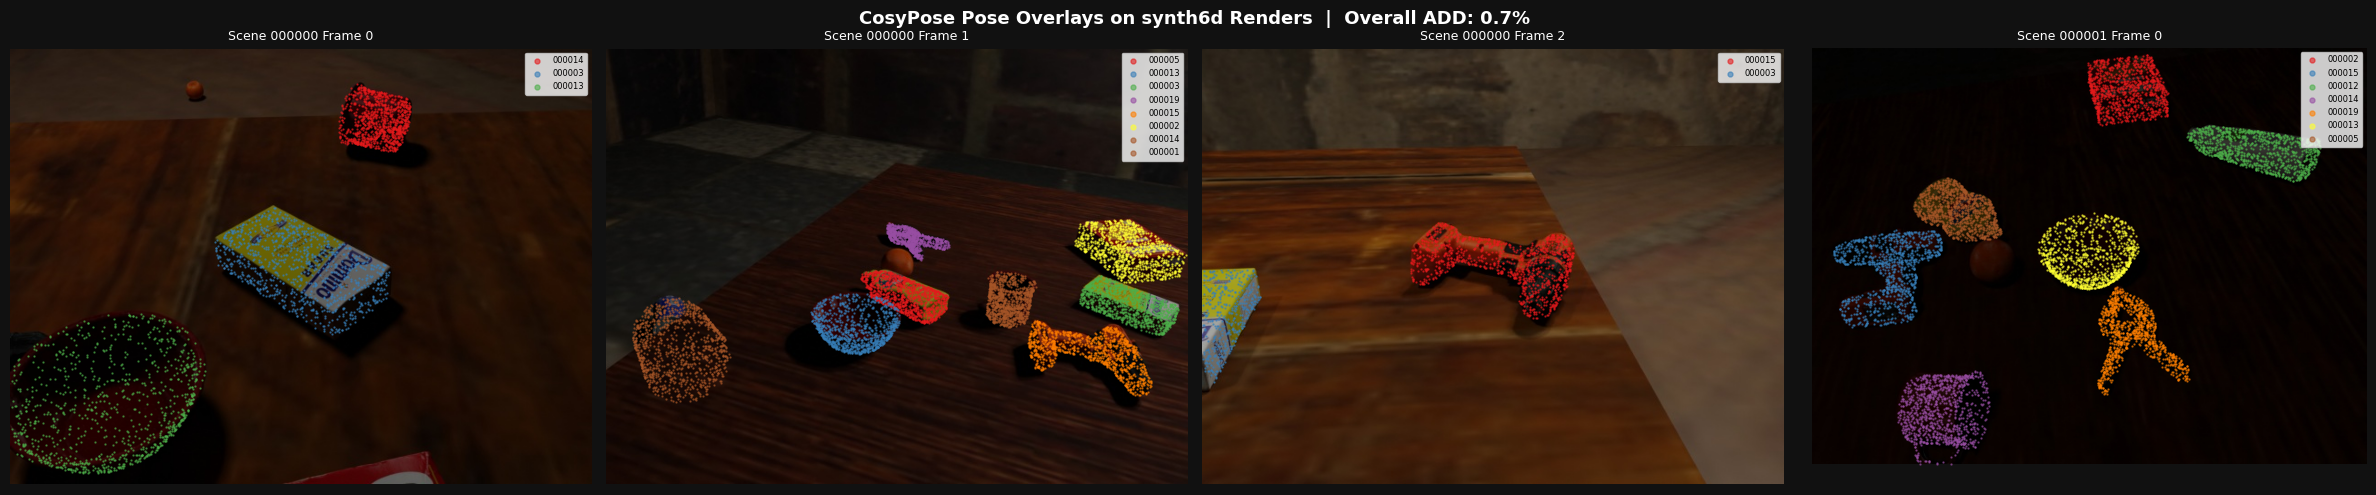

Saved to /kaggle/working/pose_overlays.png


In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D

def project_points(pts_3d, K):
    """Project 3D points to 2D using camera intrinsics K."""
    pts_h = (K @ pts_3d.T).T
    pts_2d = pts_h[:, :2] / pts_h[:, 2:3]
    return pts_2d


def draw_pose_overlay(ax, rgb, objects_with_preds, K):
    """Draw predicted pose as colored point cloud overlay on RGB image."""
    ax.imshow(rgb)
    colors = plt.cm.Set1(np.linspace(0, 1, 10))

    for i, (pred, pts) in enumerate(objects_with_preds):
        R_pred = pred["R_pred"]
        t_pred = pred["t_pred"]

        # Project model points under predicted pose
        pts_cam  = (R_pred @ pts.T).T + t_pred
        # Filter points in front of camera
        visible  = pts_cam[:, 2] > 0
        pts_2d   = project_points(pts_cam[visible], K)

        # Filter to image bounds
        h, w = rgb.shape[:2]
        in_bounds = ((pts_2d[:, 0] >= 0) & (pts_2d[:, 0] < w) &
                     (pts_2d[:, 1] >= 0) & (pts_2d[:, 1] < h))
        pts_2d = pts_2d[in_bounds]

        if len(pts_2d) > 0:
            ax.scatter(pts_2d[:, 0], pts_2d[:, 1],
                       s=0.5, c=[colors[i % len(colors)]],
                       label=pred["label"].replace("ycbv-obj_", ""),
                       alpha=0.6)

    ax.legend(loc="upper right", fontsize=6, markerscale=5)
    ax.axis("off")


# Pick up to 4 frames with predictions to visualize
N_VIZ   = 4
viz_frames = []
for frame in ALL_FRAMES:
    frame_preds = [p for p in ALL_PREDICTIONS
                   if p["scene_id"] == frame["scene_id"]
                   and p["frame_id"] == frame["frame_id"]]
    if frame_preds:
        viz_frames.append((frame, frame_preds))
    if len(viz_frames) >= N_VIZ:
        break

fig, axes = plt.subplots(1, len(viz_frames), figsize=(6 * len(viz_frames), 5))
fig.patch.set_facecolor("#111111")
if len(viz_frames) == 1:
    axes = [axes]

for ax, (frame, preds) in zip(axes, viz_frames):
    objects_with_pts = []
    for pred in preds:
        pts = get_model_pts(pred["bop_id"], n_pts=300)
        objects_with_pts.append((pred, pts))

    draw_pose_overlay(ax, frame["rgb"], objects_with_pts, frame["K"])
    ax.set_title(
        f"Scene {frame['scene_id']} Frame {frame['frame_id']}",
        color="white", fontsize=9
    )

fig.suptitle(
    f"CosyPose Pose Overlays on synth6d Renders  |  Overall ADD: {overall:.1f}%",
    color="white", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("/kaggle/working/pose_overlays.png",
            dpi=150, bbox_inches="tight", facecolor="#111111")
plt.show()
print("Saved to /kaggle/working/pose_overlays.png")